# Importan

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

In [232]:
column_names = ['Crypto_Symbol', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
data = pd.read_csv('crypto50_combined.csv', names=column_names, header=None)

for col in ['Open', 'High', 'Low', 'Close']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data.columns = data.columns.str.strip()

# Drop rows with NaNs in relevant columns AFTER initial loading and type conversion
data = data.dropna(subset=['Open', 'High', 'Low', 'Close'])

X = data[['Open', 'High', 'Low']]
y = data['Close']

print(f"Shape of data after cleaning: {data.shape}")

Shape of data after cleaning: (62354, 8)


# EDA

In [223]:
df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
MultiIndex: 62354 entries, ('LTC', '2021-08-21', np.float64(183.6514587402344)) to ('FET', '2026-02-16', np.float64(0.1735299974679947))
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   06                    62354 non-null  float64
 1   174.3670196533203     62354 non-null  float64
 2   183.62852478027344    62354 non-null  float64
 3   183.62852478027344.1  62354 non-null  float64
 4   1821956870            62354 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 5.3+ MB


,06,174.3670196533203,183.62852478027344,183.62852478027344.1,1821956870
count,62354.000000,62354.000000,62354.000000,62354.000000,6.235400e+04
mean,86.876861,80.080826,83.581212,83.581212,2.688245e+08
std,358.104202,327.780342,343.378855,343.378855,1.144565e+09
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,0.148080,0.133096,0.141071,0.141071,2.611415e+07
50%,1.274909,1.162741,1.215279,1.215279,8.900550e+07
75%,11.422050,10.466210,10.942683,10.942683,2.343677e+08
max,6339.024414,5119.550293,6012.458496,6012.458496,1.172634e+11


Semua grafik di bawah itu untuk data kolom Open

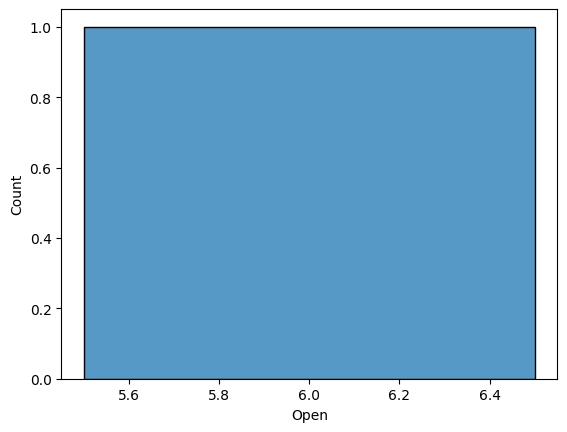

In [187]:
sns.histplot(data['Open'])
plt.show()

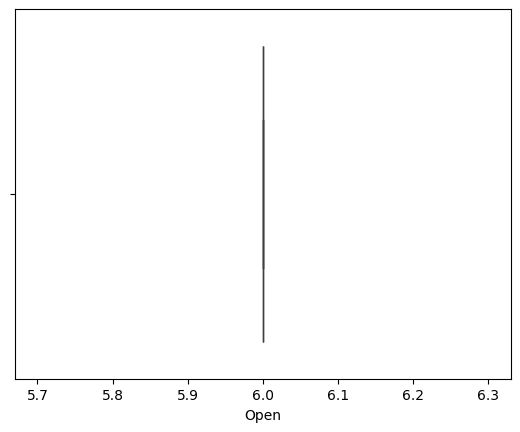

In [230]:
sns.boxplot(x=data['Open'])
plt.show()

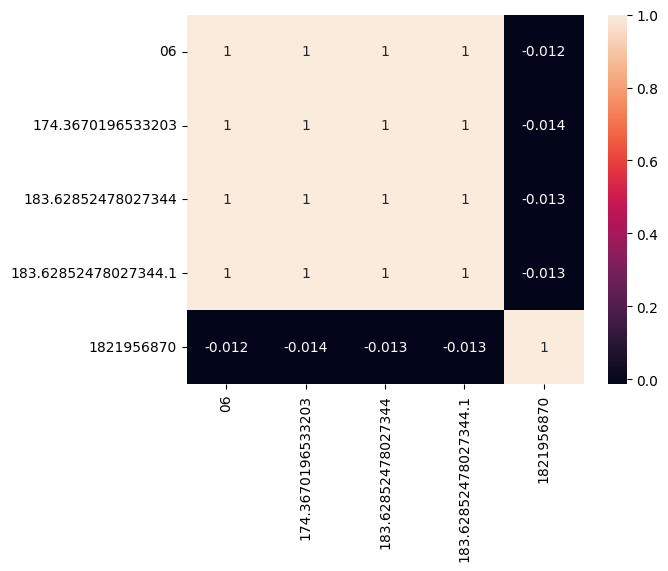

In [231]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# Preprocessing

In [209]:
scaler = StandardScaler()
numerical_cols = ['Open', 'High', 'Low']

In [210]:
df = pd.read_csv('crypto50_combined.csv')

df.isnull().sum()

,0
06,0
174.3670196533203,0
183.62852478027344,0
183.62852478027344.1,0
1821956870,0


### Tidak ada data missing di ^^^

# Supervised Learning, Regresi

In [189]:
print(X_train.dtypes)

Open    float64
High    float64
Low     float64
dtype: object


In [225]:
le = LabelEncoder()
data[['Open', 'High']] = data[['Open', 'High']].apply(le.fit_transform)

In [212]:
X_train = X_train.select_dtypes(include=['number'])
X_test = X_test.select_dtypes(include=['number'])

In [213]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [228]:
for col in ['Open', 'High', 'Low', 'Close']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['Open', 'High', 'Low', 'Close']) # Drop rows with NaNs in relevant columns

# Re-define X and y from the cleaned data
X = data[['Open', 'High', 'Low']]
y = data['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


ValueError: With n_samples=1, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [219]:

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [158]:
y_pred = model.predict(X_test.values)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [153]:
# MSE = \frac{1}{n} \sum (y - \hat{y})^2


In [159]:
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)


MSE: 354.5722206229448


In [160]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)


RMSE: 18.830088173530807


In [161]:
# R^2 = 1 - \frac{SS_{res}}{SS_{tot}}


In [162]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)


R2 Score: 0.9972193111261284


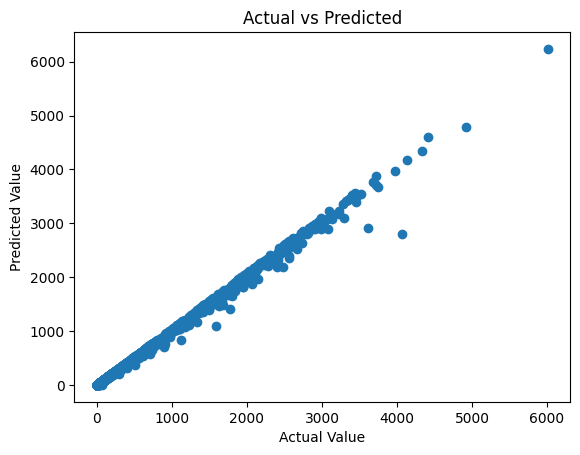

In [163]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted")
plt.show()


In [220]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

print(coefficients)


  Feature  Coefficient
0    Open     3.672168
1    High     3.672168
2     Low     1.040796


In [110]:
X

174.3670196533203  183.62852478027344  \
LTC 2021-08-21 183.651459         177.052505          179.736145   
    2021-08-22 179.907410         179.148270          186.313095   
    2021-08-23 186.132385         183.935257          187.106430   
    2021-08-24 187.304749         172.782028          173.576813   
    2021-08-25 173.709732         169.924133          177.603226   
...                                      ...                 ...   
FET 2026-02-12 0.153988             0.153906            0.158988   
    2026-02-13 0.158988             0.155946            0.164977   
    2026-02-14 0.164977             0.164954            0.180971   
    2026-02-15 0.180971             0.168727            0.173530   
    2026-02-16 0.173530             0.169666            0.173085   

                           183.62852478027344.1  
LTC 2021-08-21 183.651459            179.736145  
    2021-08-22 179.907410            186.313095  
    2021-08-23 186.132385            187.106430  
    2021-08-24 187.304749            173.576813  
    2021-08-25 173.709732            177.603226  
...                                         ...  
FET 2026-02-12 0.153988                0.158988  
    2026-02-13 0.158988                0.164977  
    2026-02-14 0.164977                0.180971  
    2026-02-15 0.180971                0.173530  
    2026-02-16 0.173530                0.173085  

[62354 rows x 3 columns]

# Ini adalah hasil ^^